In [1]:
import pandas as pd

In [2]:
import random

In [3]:
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)

  L.append(a + b)

In [4]:
len(L)

10000

In [5]:
L[:5]

[5, 7, 6, 9, 5]

In [6]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

In [7]:
import numpy as np
np.cumsum(s)

,count
2,0.0270
3,0.0830
4,0.1654
5,0.2781
6,0.4160
7,0.5786
8,0.7223
9,0.8350
10,0.9195
11,0.9725


<Axes: >

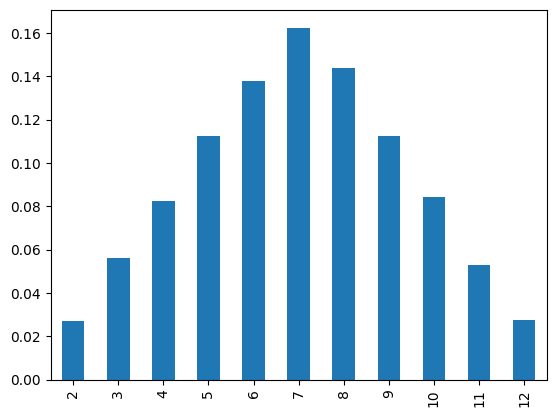

In [8]:
s.plot(kind='bar')

<Axes: >

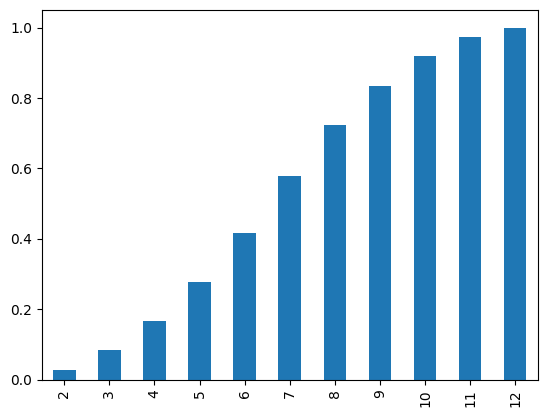

In [9]:
np.cumsum(s).plot(kind='bar')

# Parametric Density Estimation

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

sample = normal(loc=50, scale=5,size=1000)

In [11]:
sample.mean()

np.float64(50.23613924799343)

(array([  6.,  34.,  94., 195., 240., 247., 120.,  45.,  15.,   4.]),
 array([34.5277786 , 37.82650432, 41.12523004, 44.42395575, 47.72268147,
        51.02140719, 54.3201329 , 57.61885862, 60.91758434, 64.21631006,
        67.51503577]),
 <BarContainer object of 10 artists>)

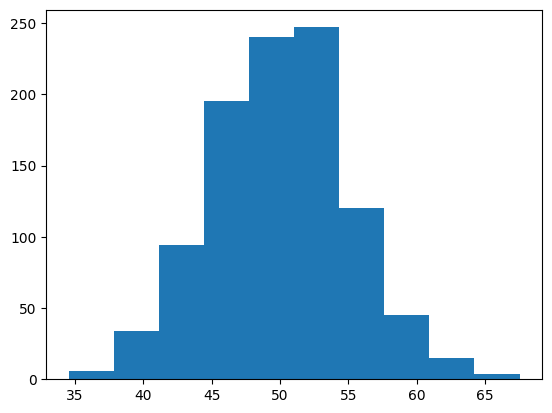

In [21]:
# plot histogram to understand the distribution of data
plt.hist(sample,bins=10)

In [22]:
# calculate sample mean and sample std dev
sample_mean = sample.mean()
sample_std = sample.std()

In [24]:
# fit the distribution with the above parameters

from scipy.stats import norm
dist = norm(sample_mean, sample_std)

In [25]:
values = np.linspace(sample.min(),sample.max(),100)

In [26]:
sample.max()

np.float64(67.51503577322569)

In [27]:
probabilities = [dist.pdf(value) for value in values]

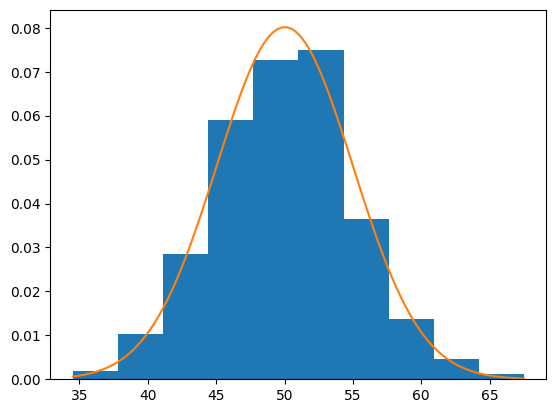

In [28]:
# plot the histogram and pdf
plt.hist(sample,bins=10,density=True)
plt.plot(values,probabilities)

/tmp/ipykernel_1120/1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

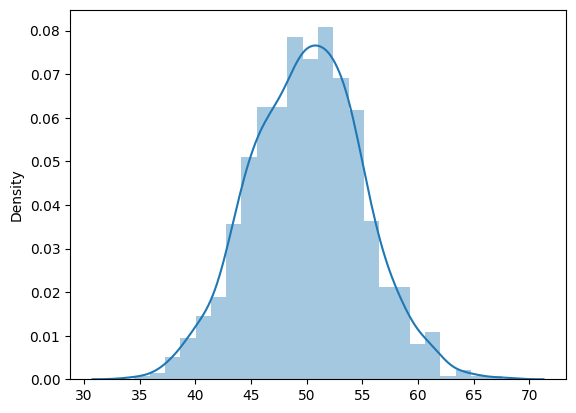

In [29]:
import seaborn as sns
sns.distplot(sample)

# KDE

In [30]:
# generate a sample
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

In [31]:
sample

array([12.23423497, 20.54056674, 15.00193374, 20.19532564, 26.09936605,
       19.2422343 , 17.68330282, 22.83857636, 18.34491975, 20.75198637,
       21.74465034, 22.73112373, 21.48121022, 18.99747005, 21.85223246,
       20.5533672 , 19.50044223, 13.88025342, 24.10508895, 20.00114002,
       11.88846029, 18.48824376, 29.33309646, 18.37674216, 23.07489333,
       23.86942898, 12.53348695, 20.36996621, 24.09009183, 18.40131282,
       21.61961181, 13.45609407, 17.96308016, 11.98384635, 19.7073107 ,
       25.85511641, 21.28118915, 18.42319135, 23.6600298 , 25.38445817,
       14.53922294, 26.37766103, 22.06511721, 21.46314727, 20.44972737,
       18.30219883, 13.76506689, 14.25635465, 21.4085162 , 22.96847303,
       21.14716421, 27.57491505, 16.84741413, 24.94542207, 18.48596454,
       17.16680962, 14.07260993, 20.62712179,  5.34688058, 20.22868633,
       29.55637895, 24.39746273, 20.8214292 , 20.62842872, 30.46548591,
       14.34381755, 26.80905649, 12.22230379, 20.33095941, 23.15

(array([ 1.,  0.,  0.,  1.,  0.,  1.,  1.,  3.,  8.,  8., 13., 19., 15.,
        14., 15., 32., 25., 38., 25., 20., 18., 15.,  5.,  7.,  7., 12.,
        15., 13., 16., 32., 42., 46., 50., 45., 58., 74., 51., 58., 55.,
        30., 33., 22., 18., 17., 11.,  2.,  3.,  3.,  1.,  2.]),
 array([ 1.30670987,  2.40265832,  3.49860678,  4.59455523,  5.69050368,
         6.78645214,  7.88240059,  8.97834904, 10.0742975 , 11.17024595,
        12.2661944 , 13.36214286, 14.45809131, 15.55403976, 16.64998822,
        17.74593667, 18.84188512, 19.93783358, 21.03378203, 22.12973048,
        23.22567894, 24.32162739, 25.41757584, 26.51352429, 27.60947275,
        28.7054212 , 29.80136965, 30.89731811, 31.99326656, 33.08921501,
        34.18516347, 35.28111192, 36.37706037, 37.47300883, 38.56895728,
        39.66490573, 40.76085419, 41.85680264, 42.95275109, 44.04869955,
        45.144648  , 46.24059645, 47.33654491, 48.43249336, 49.52844181,
        50.62439027, 51.72033872, 52.81628717, 53.91223562,

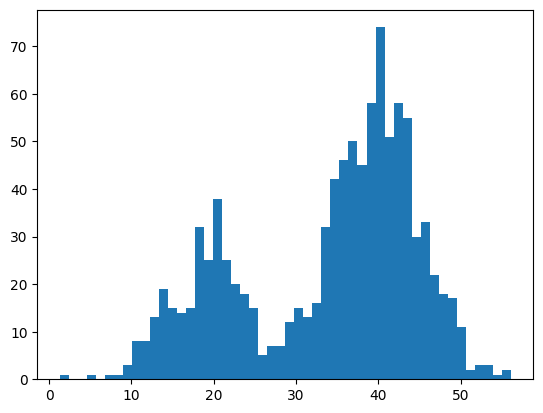

In [32]:
# plot histogram bins=50
plt.hist(sample,bins=50)

In [33]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=5, kernel='gaussian')

# convert data to a 2D array
sample = sample.reshape((len(sample), 1))

model.fit(sample)

KernelDensity(bandwidth=5)

In [34]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values), 1))

In [35]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

`score_samples(values)` returns the log-density estimate of the input samples values. This is because the `score_samples()` method of the KernelDensity class returns the logarithm of the probability density estimate rather than the actual probability density estimate.

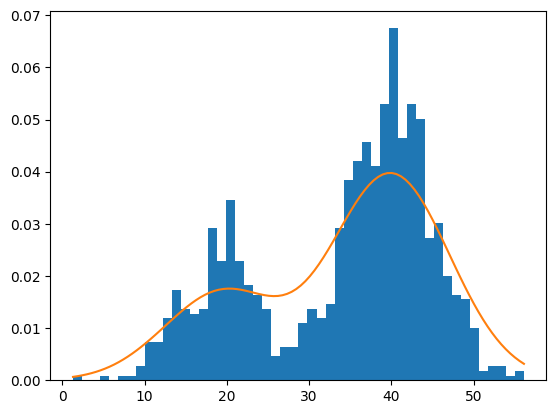

In [36]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

<Axes: ylabel='Density'>

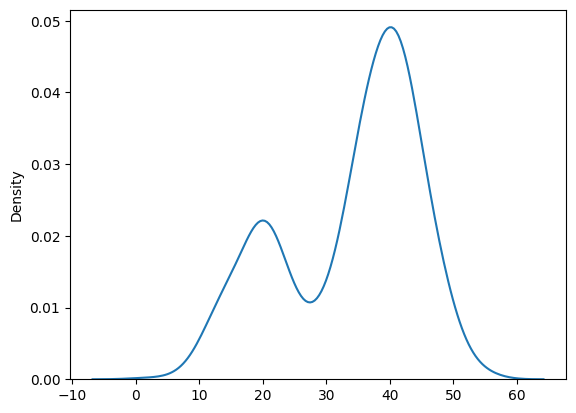

In [38]:
sns.kdeplot(sample.reshape(1000),bw_adjust=1)

In [39]:
import seaborn as sns

In [40]:
df = sns.load_dataset('iris')

In [41]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

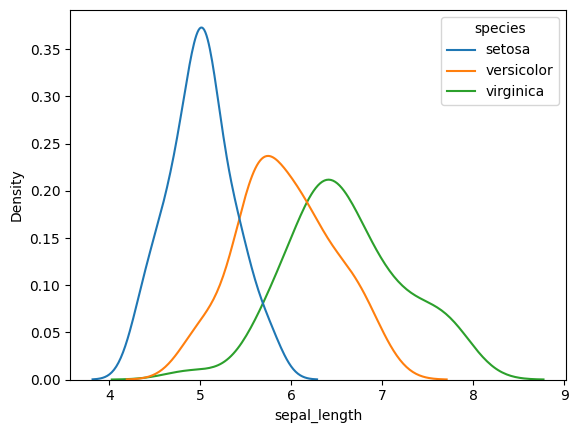

In [42]:
sns.kdeplot(data=df,x='sepal_length',hue='species')

<Axes: xlabel='sepal_width', ylabel='Density'>

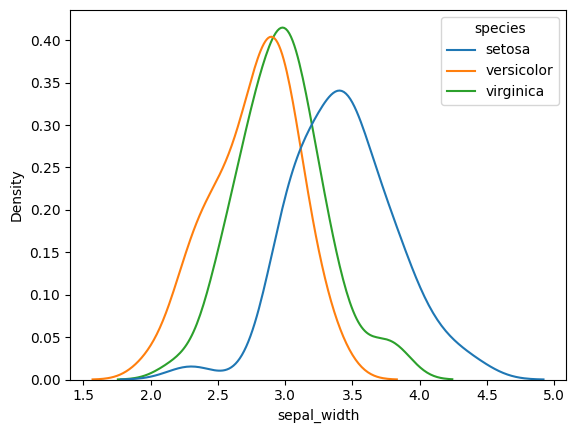

In [43]:
sns.kdeplot(data=df,x='sepal_width',hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

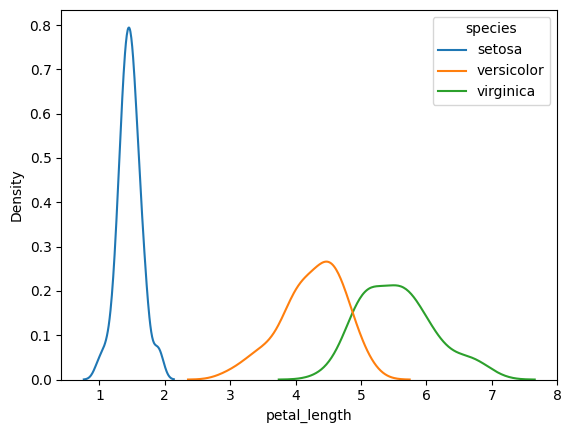

In [44]:
sns.kdeplot(data=df,x='petal_length',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

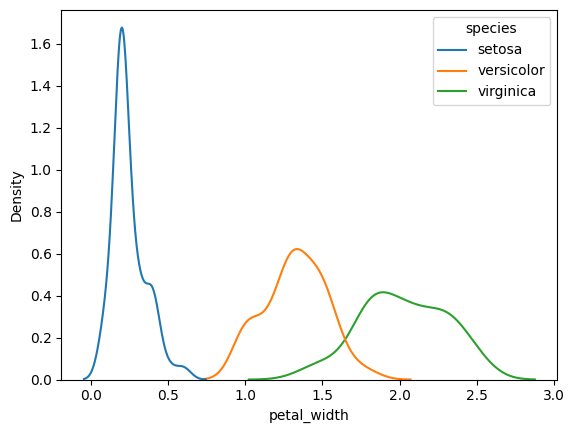

In [45]:
sns.kdeplot(data=df,x='petal_width',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

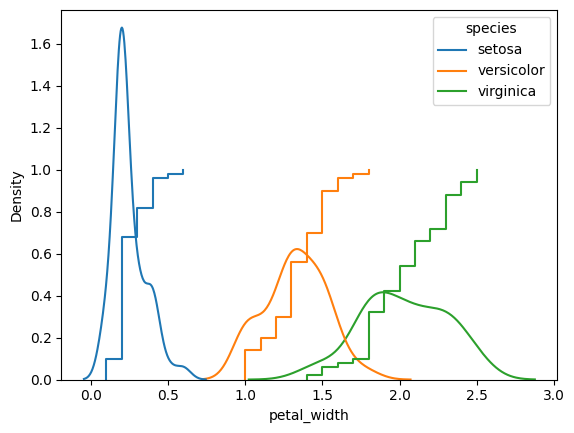

In [48]:
sns.kdeplot(data=df,x='petal_width',hue='species')
sns.ecdfplot(data=df,x='petal_width',hue='species')

In [49]:
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [50]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

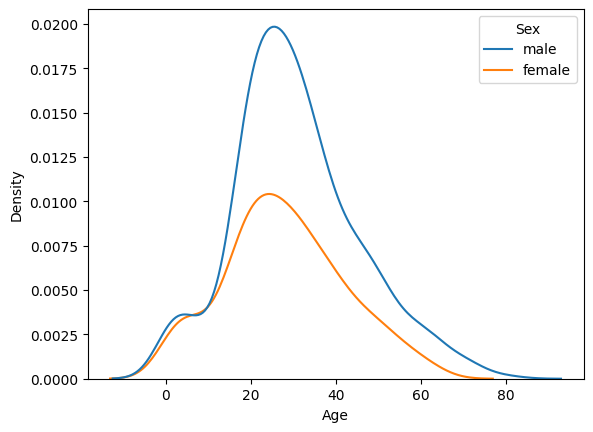

In [51]:
# code here
sns.kdeplot(data=titanic,x='Age',hue='Sex')

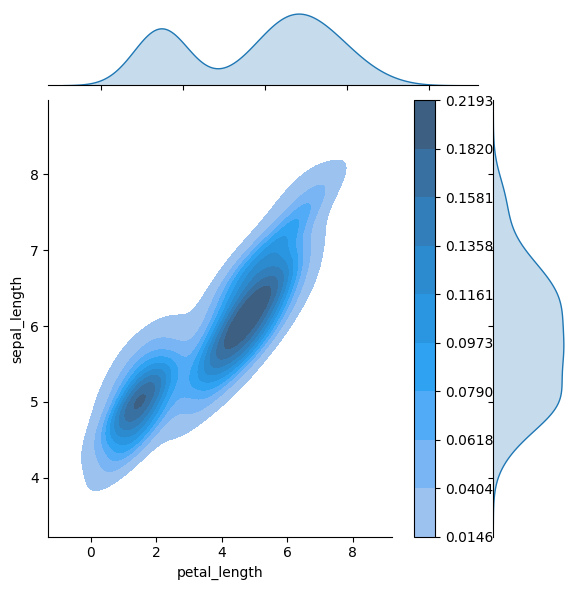

In [52]:
 sns.jointplot(data=df, x="petal_length", y="sepal_length", kind="kde",fill=True,cbar=True)

<Axes: xlabel='Age', ylabel='Density'>

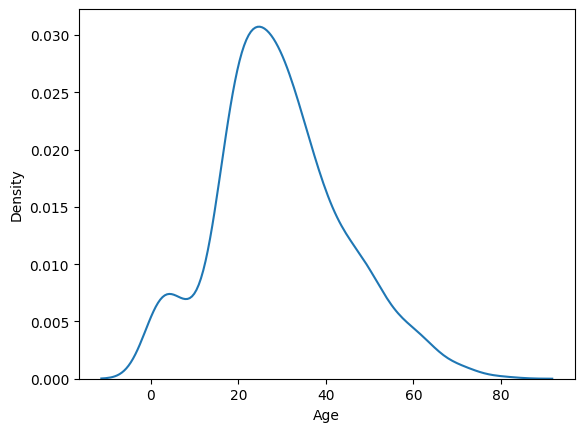

In [53]:
sns.kdeplot(titanic['Age'])

In [54]:
titanic['Age'].mean()

np.float64(29.69911764705882)

In [55]:
x = (titanic['Age'] - titanic['Age'].mean())/titanic['Age'].std()

<Axes: xlabel='Age', ylabel='Density'>

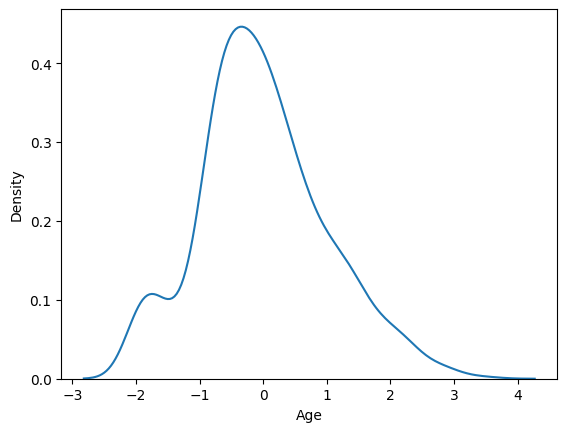

In [56]:
sns.kdeplot(x)

In [57]:
x.mean()

np.float64(2.388378943731429e-16)

In [58]:
x.std()

0.9999999999999994

In [59]:
titanic['Age'].skew()

np.float64(0.38910778230082704)

In [60]:
titanic['Age'].mean() + 3*titanic['Age'].std()

np.float64(73.27860964406095)

In [61]:
titanic['Age'].mean() - 3*titanic['Age'].std()

np.float64(-13.88037434994331)

In [62]:
titanic[titanic['Age'] > 73]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


In [63]:
titanic['Age'].max()

80.0